### Aim - annual return 10%, Sharpe>1

In [ ]:
# import Backtrader # back test
# import QuantStats # evaluate
# import Tablib # Indicator Factors

# from backtesting.test import GOOG  # from 2004.8.19 - 2013.3.1
# df = GOOG.copy()
# print(GOOG.head())
# # GOOG.tail()

'''
grid+regime filter
用波动率判断是否开grid
用趋势指标比如ADX (average direct index)判断单边行情

动量、波动率、短期回归
黑天鹅 (当天全部平仓, 不留仓位过夜)
'''

#### Data and Strategy

In [5]:
from util_BackTestM import extract_data   # baostock
from util_Grid import Strategy_GridTrading

#### Back Tester

In [7]:
import numpy as np
import pandas as pd

class Backtester:
    """
    Minimal event-driven backtester (single asset).
    - Executes at close price
    - Fee model: percent of notional per trade
    - Equity = cash + position * close
    """
    '''
    given startY,starM, endY, endM
    show timeseries + buy & sell
        Sharpe Ratio, Sortino Ratio, Max Drawdown, Turnoever, IC information coefficient
    '''

    def __init__(self, df: pd.DataFrame, strategy: Strategy_GridTrading,  # Strategy_TrendFollowing,
                 initial_cash: float = 10000.0, initial_position: float = 0.0, fee: float = 0.0005, 
                 startD=None, endD=None,
                 target_size_mode: str = "all_in"):
        self.df_raw = df.copy()
        self.strategy = strategy
        df_with_indicators = self.strategy.prepare_indicators(self.df_raw)
        self.initial_cash = float(initial_cash)
        self.initial_position = float(initial_position)
        self.fee = float(fee)
        self.target_size_mode = target_size_mode
        
        df_with_indicators["date"] = pd.to_datetime(df_with_indicators["date"])
        if startD is not None:
            df_with_indicators = df_with_indicators[df_with_indicators["date"] >= pd.Timestamp(startD)]
        if endD is not None:
            df_with_indicators = df_with_indicators[df_with_indicators["date"] <= pd.Timestamp(endD)]

        self.df = df_with_indicators


    def _init_state(self) -> dict:
        return {"cash": self.initial_cash,
            "position": self.initial_position, 
            "avg_price": np.nan,      # average price of current position, for grid scaling
            "entry_price": np.nan,
            "trades": 0,
            "fees_paid": 0.0,
            "target_size": 0.0,       # will be updated each bar if all_in
        }
    def _init_log(self):
        return []

    def run(self) -> pd.DataFrame:
        state = self._init_state()
        trade_log = self._init_log()

        equity = np.zeros(len(self.df), dtype=float)
        cash = np.zeros(len(self.df), dtype=float)
        pos = np.zeros(len(self.df), dtype=float)

        for i, (idx, row) in enumerate(self.df.iterrows()):
            close = float(row["close"])

            # Update target_size policy (all-in uses current cash)
            if self.target_size_mode == "all_in":
                state["target_size"] = state["cash"] / close if close > 0 else 0.0
            else:
                state["target_size"] = 1.0

            # Strategy decision at this bar
            self.strategy.on_bar(i, row["date"], row, state, fee=self.fee, trade_log=trade_log)

            # Mark-to-market
            equity[i] = state["cash"] + state["position"] * close
            cash[i] = state["cash"]
            pos[i] = state["position"]

        out = pd.DataFrame(
            {"equity":equity, "cash":cash, "position":pos, "close":self.df["close"].values},
            index=self.df.index
        )
        out.attrs["final_state"] = state
        return out, trade_log

    @staticmethod
    def stats(equity: pd.Series, periods_per_year: int = 252) -> dict:
        eq = equity.dropna()
        if len(eq) < 2:
            return {}

        ret = eq.pct_change().fillna(0.0)
        peak = eq.cummax()
        dd = eq / peak - 1.0

        total = float(eq.iloc[-1] / eq.iloc[0])
        years = (len(eq) - 1) / periods_per_year
        cagr = total ** (1 / years) - 1 if years > 0 else np.nan

        vol = ret.std(ddof=0)
        sharpe = (ret.mean() / vol) * np.sqrt(periods_per_year) if vol > 0 else np.nan
        maxdd = float(dd.min())
        calmar = (cagr / abs(maxdd)) if maxdd < 0 else np.nan

        return {
            "CAGR": float(cagr),
            "Sharpe": float(sharpe),
            "MaxDD": float(maxdd),
            "Calmar": float(calmar),
        }

#### Draw

In [1]:
from util_analyze import trades_to_df, plot_ohlc_box_with_volume, plot_equity_cash_position

# from backtesting.test import GOOG  # from 2004.8.19 - 2013.3.1
# df = GOOG.copy()
# print(GOOG.head())
# GOOG.tail()

### Main

login success!
logout success!
sz.000713 extracted


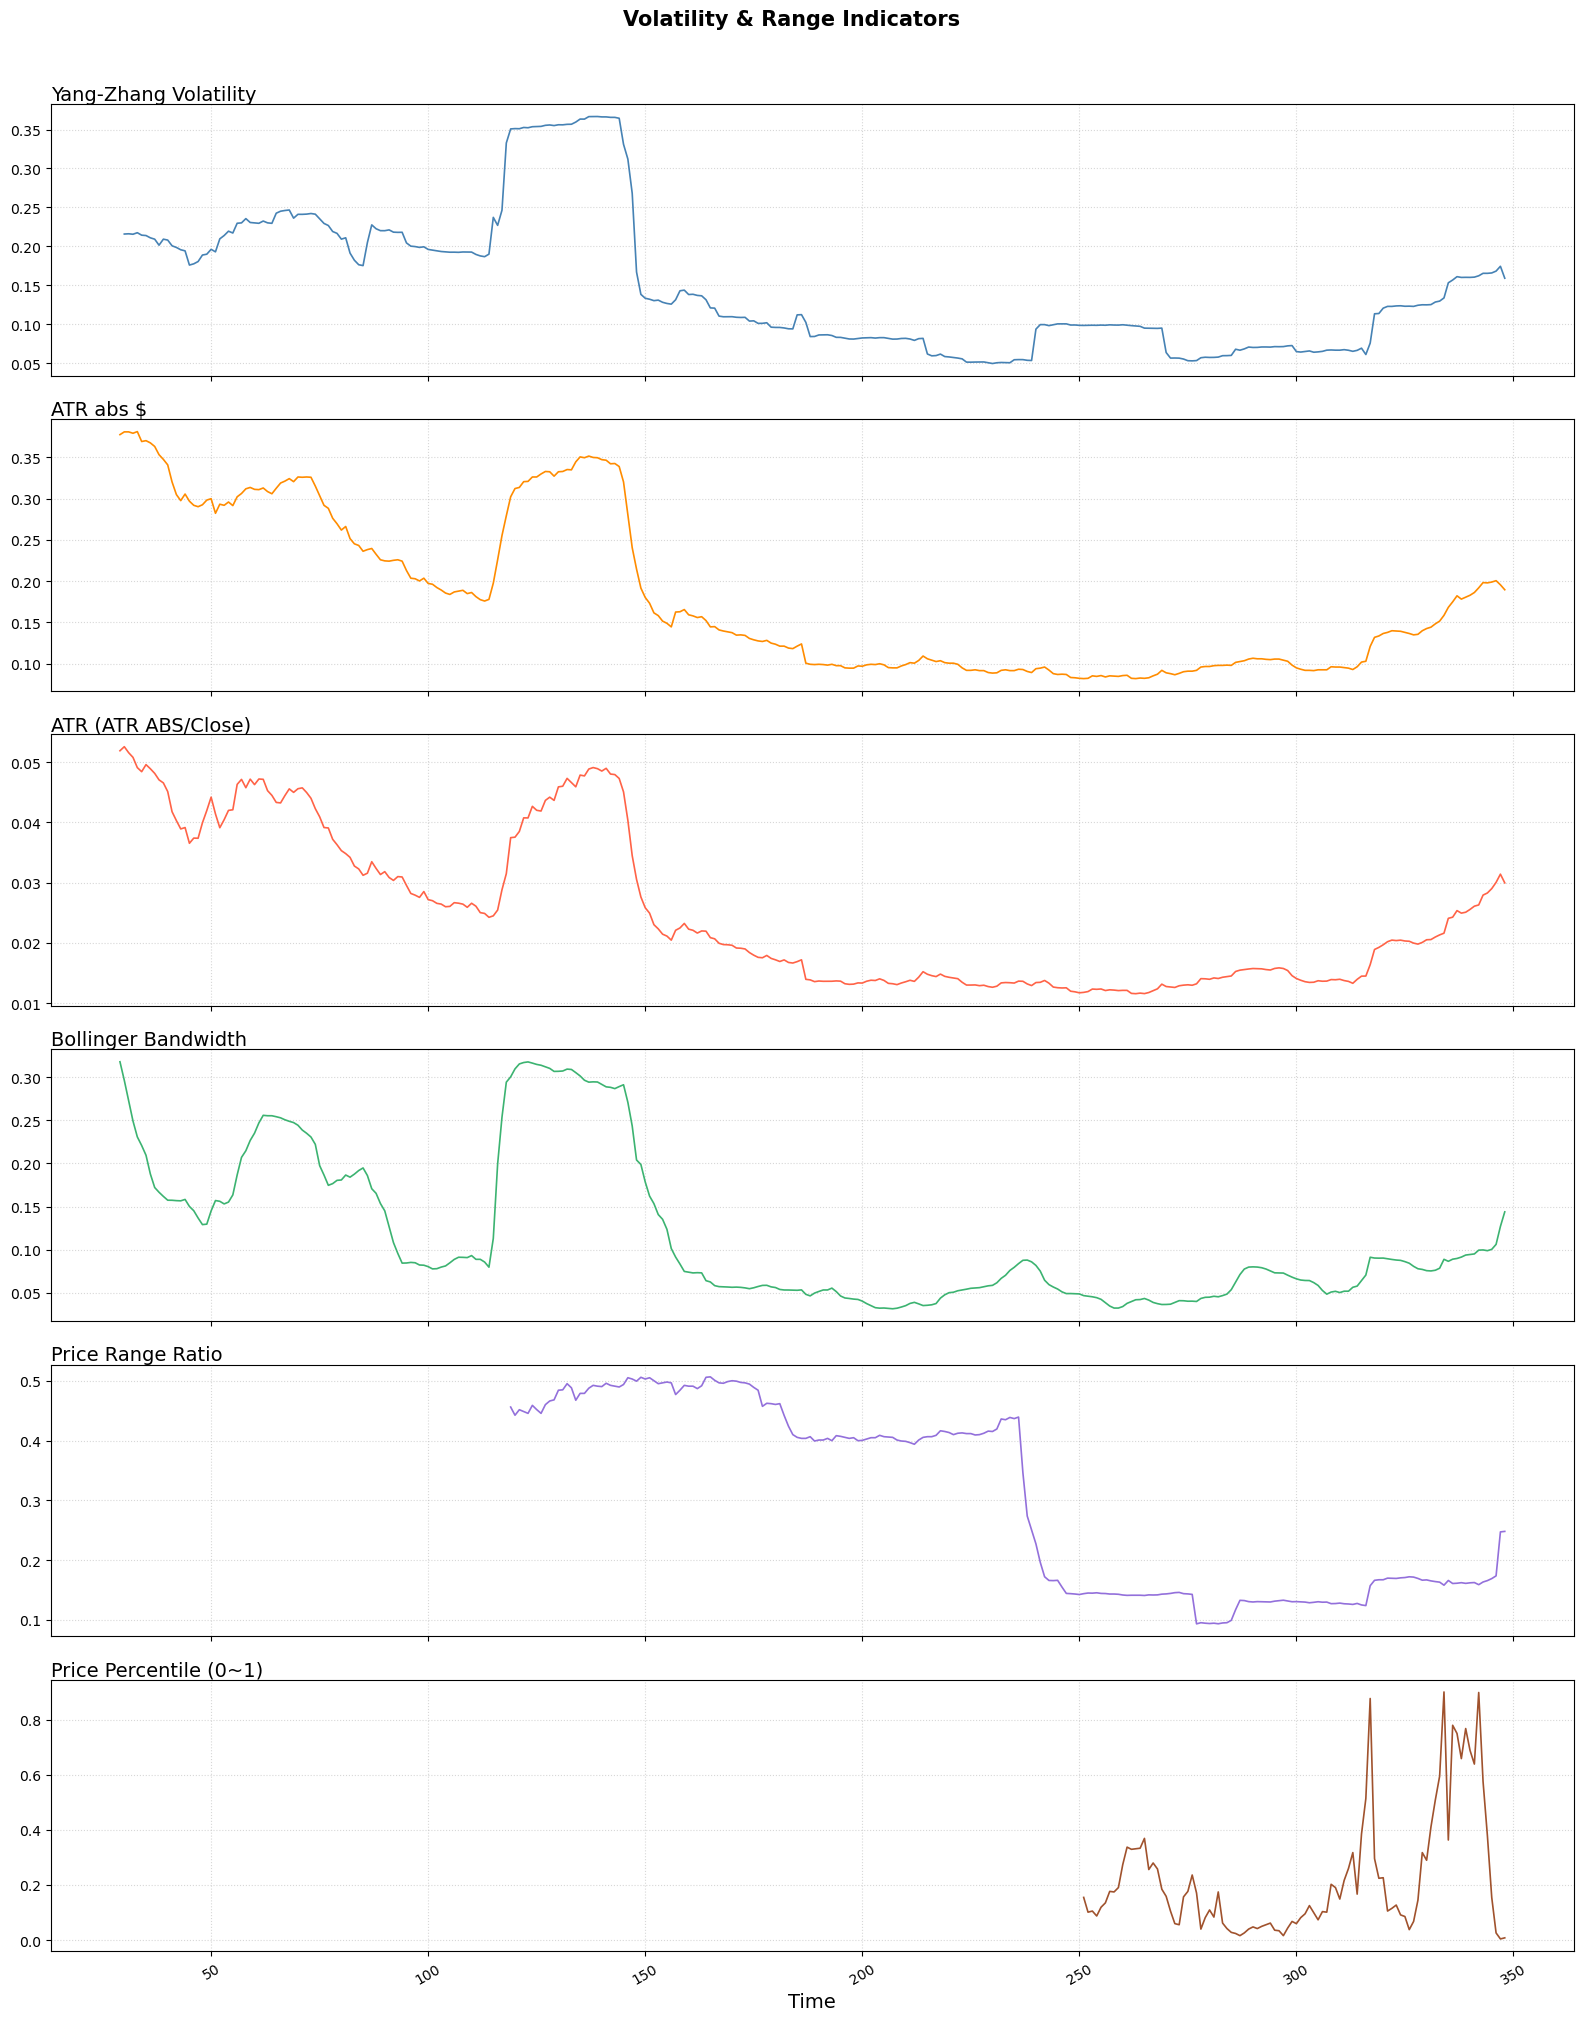

In [22]:
from util_BackTestM import extract_data
import util_Index as Index
from util_Index import volatility_indicators

stockindex = "sz.000713"   #"sz.300425"
startDate = "2024-10-16"  # "2004-08-19"
endDate = "2026-03-24"    # "2013-03-01"
# ------------ Data Prepare ------------
df = extract_data(stockIndex=stockindex, start_date=startDate, end_date=endDate)    # 1990-12-19 to now
print(f'{stockindex} extracted')

open, high, low, close = df['open'], df['high'], df['low'], df['close']
# Indexes
yz,  atr_abs, atr_pct,  bb,  prr,  ppercent = volatility_indicators(open, high, low, close, draw=True)

In [19]:
np.mean(df['open'])

np.float64(6.910377358490565)

In [21]:
_coverage

nan

In [20]:
_grid_step

np.float64(0.03595576619273301)

In [23]:
# --------------- decide params ---------------
_coverage = prr.mean() * 0.7    # bb.mean() # 覆盖70%的年化波动
_grid_step = atr_pct.iloc[-1] * 1.5
_fee  = 0.0005

min_step = 2 * _fee  # fee=0.0005 → min_step=0.001
_grid_step = max(atr_pct.iloc[-1] * 1.2, min_step * 2)

_max_layers = int(_coverage / _grid_step)

print(_coverage, _grid_step, _max_layers) 
# "sz.000713": 0.2171700050348994 0.029126213592233004 7
# "sz.300425": 0.22119836348425703 0.02293233082706766 9

0.21233759982721645 0.03595576619273301 5


[Reset Grid]: 1st time, anchor=7.3990
[Reset Grid]: 2024-12-02 00:00:00 position <= floor position
max layer: 2024-12-25 00:00:00 ---
[Hard stop2] 2025-01-27 00:00:00, new anchor = 7.5685
max layer: 2025-03-24 00:00:00 ---
[Reset Grid]: 2025-04-08 00:00:00 position <= floor position
max layer: 2025-09-18 00:00:00 ---
[Hard stop2] 2025-11-10 00:00:00, new anchor = 7.279999999999999
max layer: 2025-11-25 00:00:00 ---
[Hard stop2] 2026-01-29 00:00:00, new anchor = 7.279999999999999
max layer: 2026-03-23 00:00:00 ---


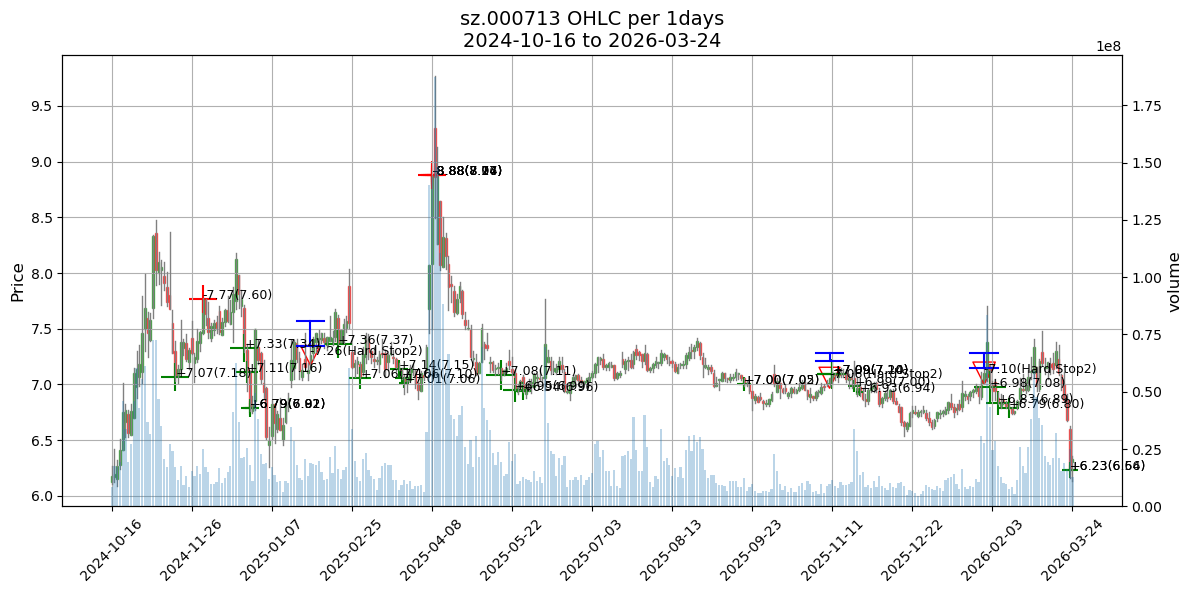

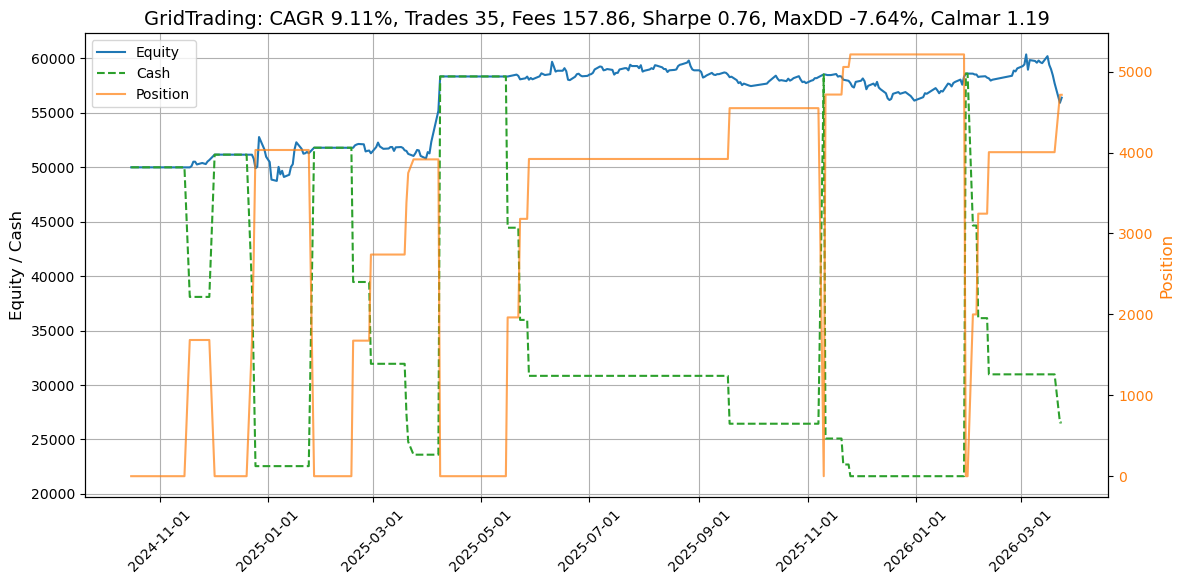

In [24]:
# -------------------------------------------------------------
# # --- trendfollowing ---
# strat = Strategy_TrendFollowing(entry_n=15, exit_n=15, atr_n=14, atr_k=2.0)
# bt = Backtester(df, strat, initial_cash=10000, fee=0.0005, 
#                 startD=stardDate, endD=endDate, 
#                 target_size_mode="all_in")
# res = bt.run()

# --- grid ---
# strat = Strategy_GridTrading(center_n=20, grid_step=0.01, max_layers=15, stop_pct=0.15, maxPositionDays=30)  # 7,10,30
strat = Strategy_GridTrading(center_n=20, grid_step=_grid_step, max_layers=_max_layers, stop_pct=0.15, maxPositionDays=30)  # 7,10,30
bt = Backtester(df, strat, initial_cash=50000, initial_position=0.0, fee=_fee, startD=startDate, endD=endDate, target_size_mode="all_in")
res, trades = bt.run()


# -------------------- Showing results -----------------------
s = bt.stats(res["equity"])
final = res.attrs["final_state"]

startDd, endDd = startDate,endDate  #"2024-08-28", "2026-03-08"    # 
plot_ohlc_box_with_volume(df, stockindex, start=startDd, end=endDd, time_period=1, trade_log=trades)
plot_equity_cash_position(res, s, final, df["date"], start=startDd, end=endDd, strategyName='GridTrading')#, showIndex=False)

In [9]:
trades = trades_to_df(trades, csv_file=f"trade_log_[{stockindex}]_{startDate}_{endDate}.csv", savelog=True)
trades

trade_log_[sz.300425]_2024-10-16_2026-03-08.csv  saved


,time,trade_time,anchor,type,layer,price,size,fee,next_buy,next_sell,position_after,notional
0,2024-11-15,0,6.0200,INITIATE,0,0.00,0.0,0.000000,5.839400,6.020000,0.0,0.00
1,2024-11-15,1,6.0200,BUY,1,5.57,1468.0,4.088380,5.839400,6.020000,1468.0,8176.76
2,2024-11-15,2,6.0200,BUY,2,5.57,1305.0,3.634425,5.694920,6.182540,2773.0,7268.85
3,2024-11-15,3,6.0200,BUY,3,5.57,1142.0,3.180470,5.581142,6.312572,3915.0,6360.94
4,2024-11-22,1,6.0200,BUY,4,5.43,566.0,1.536690,5.493370,6.414972,4481.0,3073.38
5,2024-12-17,1,6.0200,BUY,5,5.36,425.0,1.139000,5.427542,6.493967,4906.0,2278.00
6,2024-12-17,2,6.0200,BUY,6,5.36,340.0,0.911200,5.380145,6.553212,5246.0,1822.40
7,2024-12-26,1,6.0200,SELL,6,6.81,340.0,1.157700,5.348152,6.595869,4906.0,2315.40
8,2024-12-26,2,6.0200,SELL,5,6.81,425.0,1.447125,5.380145,6.553212,4481.0,2894.25
9,2024-12-26,3,6.0200,SELL,4,6.81,566.0,1.927230,5.427542,6.493967,3915.0,3854.46


#### Order Palcement

In [ ]:
# 每天挂单，买入价、卖出价设定好，出发之后按照当前价格稍微懂一点买/卖
# ?

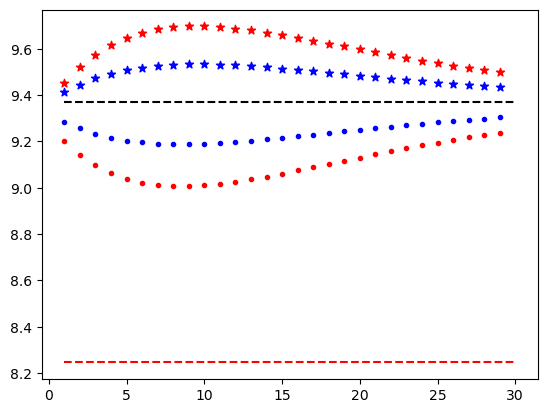

In [145]:
anchor=9.37

step=0.01
for layer in range(1,30):
    plt.scatter(layer, anchor*(1+layer*step*(0.9**layer)), color='r', marker='*') # sell
    plt.scatter(layer, anchor*(1-(layer+1)*step*(0.9**layer)), color='r', marker='.')  # buy
step=0.005
for layer in range(1,30):
    plt.scatter(layer, anchor*(1+layer*step*(0.9**layer)), color='b', marker='*') # sell
    plt.scatter(layer, anchor*(1-(layer+1)*step*(0.9**layer)), color='b', marker='.')  # buy
plt.plot([1,30], [anchor, anchor], color='k', linestyle='--')
plt.plot([1,30], [0.88*anchor, 0.88*anchor], color='red', linestyle='--')